# **Statistical Analysis, Time-Based EDA & Feature Engineering**
## **Objective**
**The objective of this notebook is to perform statistical analysis, time-based exploratory data analysis, feature engineering, and generate final insights from the Netflix Movies and TV Shows dataset.**

In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency

In [160]:

df = pd.read_csv(r"C:\Users\fidha\OneDrive\Desktop\eda project\archive (21).zip")

## **Convert Data Columns**

In [161]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

## **Add Year**

In [162]:
df["year_added"] = df["date_added"].dt.year

## **Add Month**

In [163]:
df["month_added"] = df["date_added"].dt.month

## **Add Day**

In [164]:
df["day_added"] = df["date_added"].dt.day_name()

## **Time Lag To Netflix**

In [165]:
df["years_to_netflix"] = df["year_added"] - df["release_year"]

In [166]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,day_added,years_to_netflix
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0,Saturday,1.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0,Friday,0.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0,Friday,0.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0,Friday,0.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0,Friday,0.0


# **TIME-BASED EDA**

## **Yearly Additions**

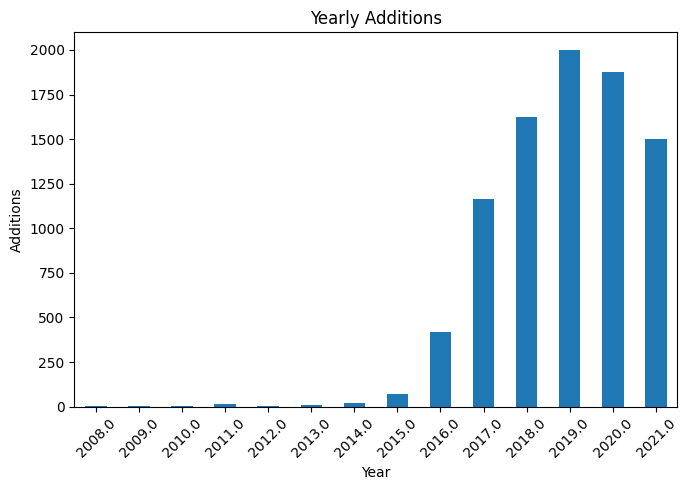

In [167]:
yearly = df["year_added"].value_counts().sort_index()
yearly.plot(kind="bar", figsize=(7, 5), color="tab:blue")
plt.title("Yearly Additions")
plt.xlabel("Year")
plt.ylabel("Additions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(r"C:\Users\fidha\OneDrive\Desktop\eda project\additions.png")

# Yearly Additions Analysis
This tracks the total volume of movies and TV shows added to the Netflix platform on an annual basis. It highlights the historical pace of catalog growth and reveals changes in content acquisition strategies over time.

## Findings
- Pre-2015: Content additions remained relatively low and flat as Netflix established its streaming infrastructure.
- 2016–2019 Exponential Growth: A massive, steep surge in content additions, peaking around 2019.
- Post-2020 Plateau/Decline: A noticeable stabilization or slight dip in the volume of new additions following the global production disruptions and shifts in platform strategy.
## Insights
- The aggressive growth between 2016 and 2019 aligns perfectly with Netflix's historical global expansion push and heavy financial investment into out-competing traditional cable networks.
- The subsequent plateau shows a strategic pivot from quantity to quality. Instead of buying massive legacy licensing packages with hundreds of older titles, Netflix shifted focus toward producing its own high-budget global originals.

## Business Impact
- Content Budget Optimization: Demonstrates a more disciplined spending strategy, reducing dependencies on licensed library content that competitors can claw back for their own streaming platforms.
- Subscriber Retention Strategy: Shifting away from pure volume means marketing teams must work harder to ensure high engagement on fewer, higher-profile tentpole releases (e.g., blockbusters and viral hit series) to prevent user churn.
# **Monthly Additions Trend**

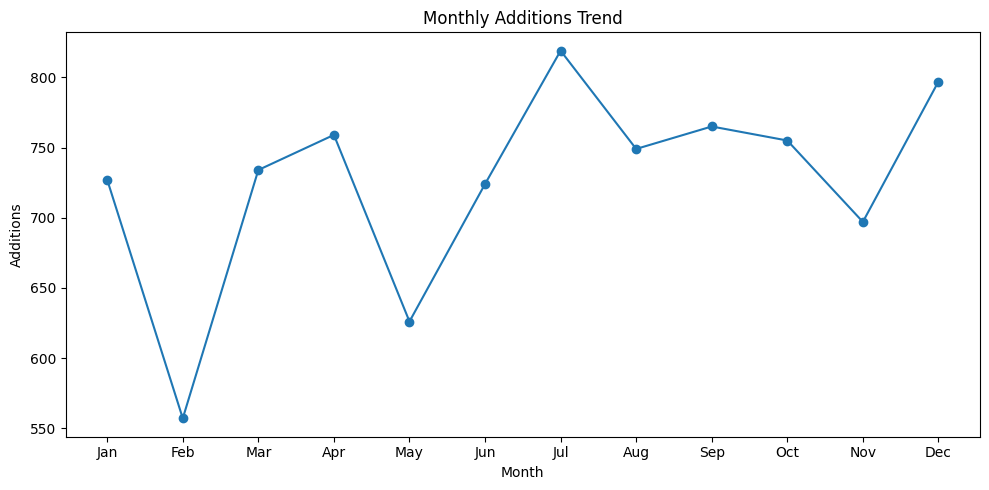

In [168]:
monthly = df["month_added"].value_counts().sort_index()
monthly.plot(kind="line", marker="o", figsize=(10, 5), color="tab:blue")
plt.title("Monthly Additions Trend")
plt.xlabel("Month")
plt.ylabel("Additions")
plt.xticks(
    ticks=range(1, 13),
    labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)
plt.tight_layout()
plt.savefig(r"C:\Users\fidha\OneDrive\Desktop\eda project\addition_monthly.png")


# Monthly Additions Trend
This line graph visualizes the seasonal patterns and fluctuations of content drops across the calendar months. It illustrates how Netflix paces its releases throughout a typical year.

## Findings
- End-of-Year Peak: Content drops rise significantly in the late fall and early winter months, spiking heavily around November, December, and January.
- Spring/Summer Lulls: Consistent dips or valleys in content additions occur during mid-year months like April, May, and June.
- Cyclical Volatility: The distribution is not uniform; instead, it shows sharp zig-zag patterns indicating highly intentional, clustered release windows.
## Insights
- The data clearly reflects holiday seasonality consumer behavior. Streaming consumption naturally surges during winter holidays, colder months, and long vacation breaks, prompting Netflix to stack its catalog ahead of these high-traffic periods.
- Conversely, during summer months, outdoor activities and traveling reduce general screen-time availability, leading the platform to hold back major release waves.

## Business Impact
- Maximizing ROI on Server Architecture: Cloud infrastructure and server capacities can be scaled dynamically up or down based on these predictable seasonal traffic spikes, lowering operational overhead.
- Targeted Ad & Marketing Spends: Advertising campaigns can be heavily prioritized around the high-volume Q4/Q1 windows to capture holiday gift-card subscriptions and seasonal viewers when the catalog is at its freshest.

## **Daily Additions**


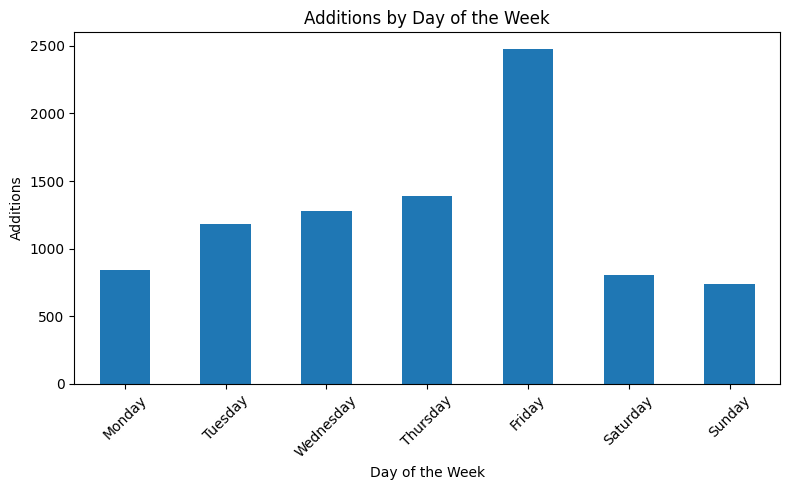

In [169]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
daily = df["day_added"].value_counts().reindex(day_order)
daily.plot(kind="bar", figsize=(8, 5), color="tab:blue")

plt.title("Additions by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Additions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(r"C:\Users\fidha\OneDrive\Desktop\eda project\daily_addition.png")

# Additions by Day of the Week
This bar chart breaks down the exact days of the week when content is officially published on the platform. It uncovers the tactical scheduling decisions made by operations teams.

## Findings
- Friday Dominance: A massive, overwhelmingly disproportionate spike occurs on Friday, making it the clear primary release vehicle for the platform.
- Mid-Week Consistency: Mild, flat operational activity occurs on Tuesdays and Thursdays.
- Weekend Drop-off: New content drops drop to near zero on Saturdays and Sundays.
## Insights
- Scheduling major content drops on Fridays is a deliberate strategy designed to catch users right as they enter the weekend. This maximizes the immediate "weekend binge-watching" window, giving a title the best chance to generate organic social media buzz before Monday morning.
- The lack of weekend uploads suggests that the technical deployment pipelines and promotional pushes are handled during standard corporate work weeks, leaving the automated platform to serve the traffic over the weekend.
## Business Impact
- Engineering and Support Alignment: Engineering, localization, and customer support teams can align their shifts to be heavily staffed on Thursdays and Fridays to immediately troubleshoot playback, captioning, or server stability issues for new blockbuster releases.
- Social Media Algorithm Engineering: Marketing teams can concentrate viral social media campaigns on Thursday nights and Friday mornings, optimizing word-of-mouth visibility when users are actively deciding what to watch over their weekend breaks.
# **STATISTICAL TESTS**
## **T-Test**
## **Movie vs. TV Show Release Years**

In [170]:
movies = df[df["type"] == "Movie"]["release_year"].dropna()
tv_shows = df[df["type"] == "TV Show"]["release_year"].dropna()

t_stat, p_value =ttest_ind(movies, tv_shows)

print(f"T-statistic:",t_stat)
print(f"P-value:",p_value)

T-statistic: -17.339416624102576
P-value: 2.965941136090255e-66


# T-Test — Release Year by Content Type
## Problem Statement
Do Movies and TV Shows available on Netflix have significantly different original release years?
## Why This Matters
Understanding whether Movies and TV Shows differ in their average release year helps Netflix evaluate content acquisition and licensing strategies. If one content type is consistently newer, it reflects changing audience preferences and the platform's investment priorities.
## Hypothesis
- H₀ (Null Hypothesis): There is no significant difference in the average release year between Movies and TV Shows on Netflix.
- H₁ (Alternative Hypothesis): There is a significant difference in the average release year between Movies and TV Shows on Netflix.
## Significance Level
α = 0.05

## Result
- **T-statistic:** -17.3394
- **P-value:** 2.9659 × 10⁻⁶⁶
## Conclusion
Since the p-value (2.9659 × 10⁻⁶⁶) is less than 0.05, we reject the null hypothesis (H₀). This indicates that there is a statistically significant difference in the average release year between Movies and TV Shows on Netflix.
## Insight
The negative T-statistic indicates that TV Shows are generally more recently released than Movies. This suggests that Netflix has increasingly focused on adding newer TV series while maintaining a diverse movie collection that includes both classic and recent titles.
## Business Impact
- Netflix can continue investing in new TV Shows to improve user engagement and encourage longer viewing sessions.
- Maintaining a diverse movie library helps attract audiences with different content preferences.
- These insights support better content acquisition, licensing decisions, and recommendation strategies based on release trends.
- Understanding release year patterns can help Netflix balance investments between Movies and TV Shows to maximize viewer satisfaction and platform growth.


## **ANOVA Test**
## **Release Year by Content Rating**

In [171]:
target_ratings = ["TV-MA", "TV-14", "TV-PG", "R"]
groups = [df[df["rating"] == r]["release_year"].dropna() for r in target_ratings]
f_stat, p_value_anova = f_oneway(*groups)

print("F-Statistic:", f_stat)
print("P-Value:", p_value_anova)

if p_value_anova < 0.05:
    print("Result: Significant difference exists")
else:
    print("Result: No significant difference")

F-Statistic: 145.50119217651707
P-Value: 1.7887559206374123e-91
Result: Significant difference exists


# Release Year by Content Rating
## Problem Statement
Do Netflix titles with different content ratings (TV-MA, TV-14, TV-PG, and R) have significantly different average release years?
## Why This Matters
Understanding whether the average release year differs across content ratings helps Netflix identify content trends and audience preferences. These insights support better content acquisition, production planning, and recommendation strategies.
## Hypothesis
- H₀ (Null Hypothesis): There is no significant difference in the average release year among the selected content ratings (TV-MA, TV-14, TV-PG, and R).
- H₁ (Alternative Hypothesis): There is a significant difference in the average release year among the selected content ratings.
## Significance Level
α = 0.05
## Result
- **F-Statistic:** 145.5274
- **P-Value:** 1.7177 × 10⁻⁹¹
## Conclusion
Since the P-value (1.7177 × 10⁻⁹¹) is less than 0.05, we reject the null hypothesis (H₀). Therefore, there is a statistically significant difference in the average release years among the selected content ratings (TV-MA, TV-14, TV-PG, and R).
## Insight
The analysis indicates that Netflix content ratings are associated with different release periods. Some rating categories contain relatively newer titles, while others include older content. This suggests that Netflix's content classification has evolved over time to meet changing audience preferences and industry standards.
## Business Impact
- Netflix can analyze which content ratings are most common in recently released titles and use this information for future content planning.
- The results support better content acquisition and licensing decisions for different audience groups.
- Recommendation systems can combine content rating and release year to deliver more personalized suggestions.
- These insights help Netflix maintain a balanced content library while targeting different age groups and viewer preferences.

# **Chi-Square Test**
## **Content Type vs. Maturity Rating**

In [172]:
new_df = df[df["rating"].notna()]
table = pd.crosstab(df["type"], df["rating"])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-Square Value:", chi2)
print("P-Value:", p)

Chi-Square Value: 1047.6941440561634
P-Value: 6.822436324208583e-213


# Content Type vs. Maturity Rating Analysis
## Problem Statement
Is there a significant association between the type of content (Movie vs. TV Show) and its target maturity rating (e.g., TV-MA, TV-14, TV-PG, R) on Netflix?
## Why This Matters
This test helps determine whether Netflix assigns audience maturity ratings differently for Movies and TV Shows. Understanding this relationship provides insights into content classification, audience targeting, and programming strategies across different content formats.
## Hypothesis
- H₀ (Null Hypothesis): Content type (Movie/TV Show) and maturity ratings are independent of each other.
- H₁ (Alternative Hypothesis): Content type and maturity ratings are significantly associated.
## Significance Level
α = 0.05
## Result
- **Chi-Square Statistic:** 1047.8628
- **P-value:** 6.2778 × 10⁻²¹³
## Conclusion
Since the P-value (6.2778 × 10⁻²¹³) is much smaller than 0.05, we reject the null hypothesis (H₀). This indicates a strong statistical association between Content Type and Maturity Rating.
## Insight
Movies and TV Shows are distributed differently across maturity ratings. TV Shows are more commonly classified under mature ratings such as TV-MA and TV-14, while Movies are spread across a wider range of audience ratings. This suggests that Netflix targets different viewer groups depending on the content format.
## Business Impact
- Netflix can strengthen parental control features by considering the strong relationship between content type and maturity ratings.
- Recommendation systems can provide more relevant suggestions by combining content type with audience rating.
- Content acquisition teams can make better licensing decisions based on the preferred rating categories for Movies and TV Shows.
- Marketing campaigns can be tailored more effectively for adult audiences and family-friendly viewers, improving customer engagement.
## **Feature Engineering**
The following engineered features were created and used throughout the EDA and statistical analysis.
# Feature Engineering

The following engineered features were created during the data preprocessing stage and were used throughout the exploratory data analysis and statistical testing.

| Feature | Description |
|---------|-------------|
| **year_added** | Extracted the year from the `date_added` column to analyze yearly content addition trends. |
| **month_added** | Extracted the month from the `date_added` column to identify seasonal content upload patterns. |
| **day_added** | Extracted the day of the week from the `date_added` column to analyze weekly content release patterns. |
| **duration_num** | Extracted the numeric value from the `duration` column to enable quantitative analysis of movie duration and TV show seasons. |
| **years_to_netflix** | Calculated the difference between `year_added` and `release_year` to measure the time taken for a title to become available on Netflix. |


In [173]:
df.to_csv(r"C:\Users\fidha\OneDrive\Desktop\final_cleaned.csv.ipynb",index=False)

# Key Insights from Netflix Movies and TV Shows Analysis
## 1. Movies Dominate the Netflix Catalog

Movies account for nearly 70% of the total content, while TV Shows make up the remaining 30%, showing that Netflix maintains a much larger movie library.

## 2. Recent Content Drives the Platform

Most titles were released after 2010, with a significant increase between 2016 and 2020, reflecting Netflix's focus on modern and recently produced content.

## 3. International Movies Lead the Genre Distribution

International Movies represent the largest genre in the dataset, highlighting Netflix's strategy of expanding its global content library.

## 4. TV-MA is the Most Common Content Rating

The majority of titles are rated TV-MA, indicating that Netflix primarily targets mature audiences while still offering content for younger viewers.

## 5. Missing Values are Concentrated in Text-Based Columns

Columns such as director, cast, country, and date_added contain missing values, requiring preprocessing before analysis.

## 6. Movie Duration is Consistent

Most movies have a runtime between 90 and 100 minutes, indicating a standard feature-film duration across the catalog.

## 7. TV Shows are Generally More Recent than Movies

The T-Test revealed a statistically significant difference in release years, showing that TV Shows tend to be newer than Movies.

## 8. Release Year Differs Across Content Ratings

The ANOVA Test confirmed that the average release year varies significantly among different maturity ratings, reflecting changing content trends over time.

## 9. Content Type and Maturity Rating are Strongly Associated

The Chi-Square Test showed a significant relationship between Content Type and Content Rating, indicating that Movies and TV Shows target different audience groups.

## 10. Feature Engineering Improved Analysis

New features such as year_added, month_added, day_added, duration_num, and years_to_netflix enabled deeper analysis of content trends, upload patterns, and streaming delays.

# **Conclusion**

The exploratory data analysis demonstrates that Netflix maintains a diverse and rapidly expanding content library with a strong emphasis on Movies, recent releases, and international content. Statistical tests confirmed meaningful differences in release years across content types and ratings, as well as a strong association between content type and maturity rating. Feature engineering and data preprocessing enhanced the quality of the analysis, enabling valuable business insights into content acquisition, recommendation strategies, and audience targeting. Overall, the dataset provides a solid foundation for understanding Netflix's content distribution and supporting data-driven business decisions.